In [15]:
import numpy as np
import matplotlib.pyplot as plt

In [16]:
fs = 8000
fc = 1000
N = 21
M = N // 2

In [17]:
wc = 2 * np.pi * fc / fs

In [18]:
h_ideal = []

for n in range(N):
    if n == M:
        h_ideal.append(wc / np.pi)
    else:
        h_ideal.append(np.sin(wc * (n - M)) / (np.pi * (n - M)))

In [19]:
hamming = 0.54 - 0.46 * np.cos(2 * np.pi * n / (N - 1))


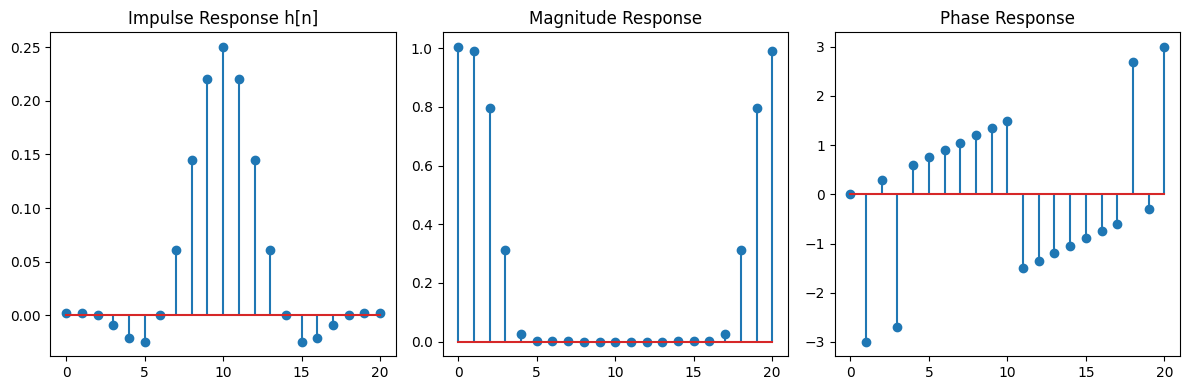

FIR Filter Coefficients (using sinc):
[ 2.54647909e-03  2.56375081e-03 -1.63579163e-18 -8.66936394e-03
 -2.11067138e-02 -2.43085405e-02  6.64782352e-18  6.07999526e-02
  1.45172834e-01  2.20011648e-01  2.50000000e-01  2.20011648e-01
  1.45172834e-01  6.07999526e-02  6.64782352e-18 -2.43085405e-02
 -2.11067138e-02 -8.66936394e-03 -1.63579163e-18  2.56375081e-03
  2.54647909e-03]


In [21]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# GIVEN
# =========================
fs = 8000
fc = 1000
N = 21
M = (N - 1) // 2

n = np.arange(N)

# =========================
# STEP 1: NORMALIZED CUTOFF
# =========================
wc = 2 * np.pi * fc / fs

# =========================
# STEP 2: IDEAL IMPULSE RESPONSE (SINC METHOD)
# =========================
# np.sinc(x) = sin(pi x) / (pi x)

hd = 2 * fc / fs * np.sinc(2 * fc * (n - M) / fs)

# =========================
# STEP 3: HAMMING WINDOW
# =========================
w = 0.54 - 0.46 * np.cos(2 * np.pi * n / (N - 1))

# =========================
# STEP 4: FINAL FIR FILTER
# =========================
h = hd * w

# =========================
# STEP 5: DFT (FREQUENCY RESPONSE)
# =========================
H = np.zeros(N, dtype=complex)

for k in range(N):
    for i in range(N):
        H[k] += h[i] * np.exp(-1j * 2 * np.pi * k * i / N)

magnitude = np.abs(H)
phase = np.angle(H)

# =========================
# STEP 6: PLOTS
# =========================
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.stem(n, h)
plt.title("Impulse Response h[n]")

plt.subplot(1,3,2)
plt.stem(magnitude)
plt.title("Magnitude Response")

plt.subplot(1,3,3)
plt.stem(phase)
plt.title("Phase Response")

plt.tight_layout()
plt.show()

# =========================
# PRINT FILTER COEFFICIENTS
# =========================
print("FIR Filter Coefficients (using sinc):")
print(h)